# 다중공선성 분석

- **입력**: `260510_features/Membership_features.csv`
- VIF > 10: 심각 / VIF 5~10: 주의 / VIF < 5: 양호
- **⚠️ XGBoost는 다중공선성에 강함 → VIF는 참고용, 최종 판단은 SHAP**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('..').resolve()
df_raw = pd.read_csv(
    BASE / '_data/02_interim/260510_features/Membership_features.csv',
    encoding='utf-8-sig'
)
print(f'shape: {df_raw.shape}')
df_raw.head(3)

shape: (23343, 100)


,USER_KEY,product_code,price,billing_method,is_churn_prevented,payment_device,is_user_verified,gender,age,is_repurchase,...,family_ratio,drama_ratio,action_ratio,thriller_ratio,sf_ratio,comedy_ratio,romance_ratio,action_sf_thriller_affinity,family_content_affinity,genre_entropy_norm
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,0,pc,1,F,20.0,1,...,0.0769,0.2308,0.3077,0.2308,0.0,0.0,0.0769,1.0,0.0,0.9105
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,pc,1,F,25.0,0,...,0.0000,0.3333,0.6667,0.0000,0.0,0.0,0.0000,1.0,0.0,0.9183
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,0,android,1,F,20.0,0,...,0.0000,0.0000,0.0000,0.5000,0.0,0.5,0.0000,1.0,0.0,1.0000


In [2]:
# 분석 제외 컬럼
DROP = [
    # 식별자/날짜/문자열
    'USER_KEY','product_code','payment_device','device_group',
    'gender','age_group',
    # 타겟
    'is_repurchase',
    # 상수 또는 이미 파생변수로 대체된 원본
    'is_promotion',
    # 완전 중복 쌍
    'vh_title_div_per_day',  # contents_per_active_day와 동일
    'sessions_per_active_day',  # watch_per_day와 동일
]
DROP = [c for c in DROP if c in df_raw.columns]

df = df_raw.drop(columns=DROP)
df_num = df.select_dtypes(include=[np.number]).fillna(0)

# 분산 0 컬럼 제거
zero_var = df_num.columns[df_num.var() == 0].tolist()
if zero_var:
    print(f'분산=0 제거: {zero_var}')
    df_num = df_num.drop(columns=zero_var)

print(f'분석 대상 변수: {df_num.shape[1]}개')

분산=0 제거: ['verified_x_age']
분석 대상 변수: 90개


## 1. 상관관계 히트맵

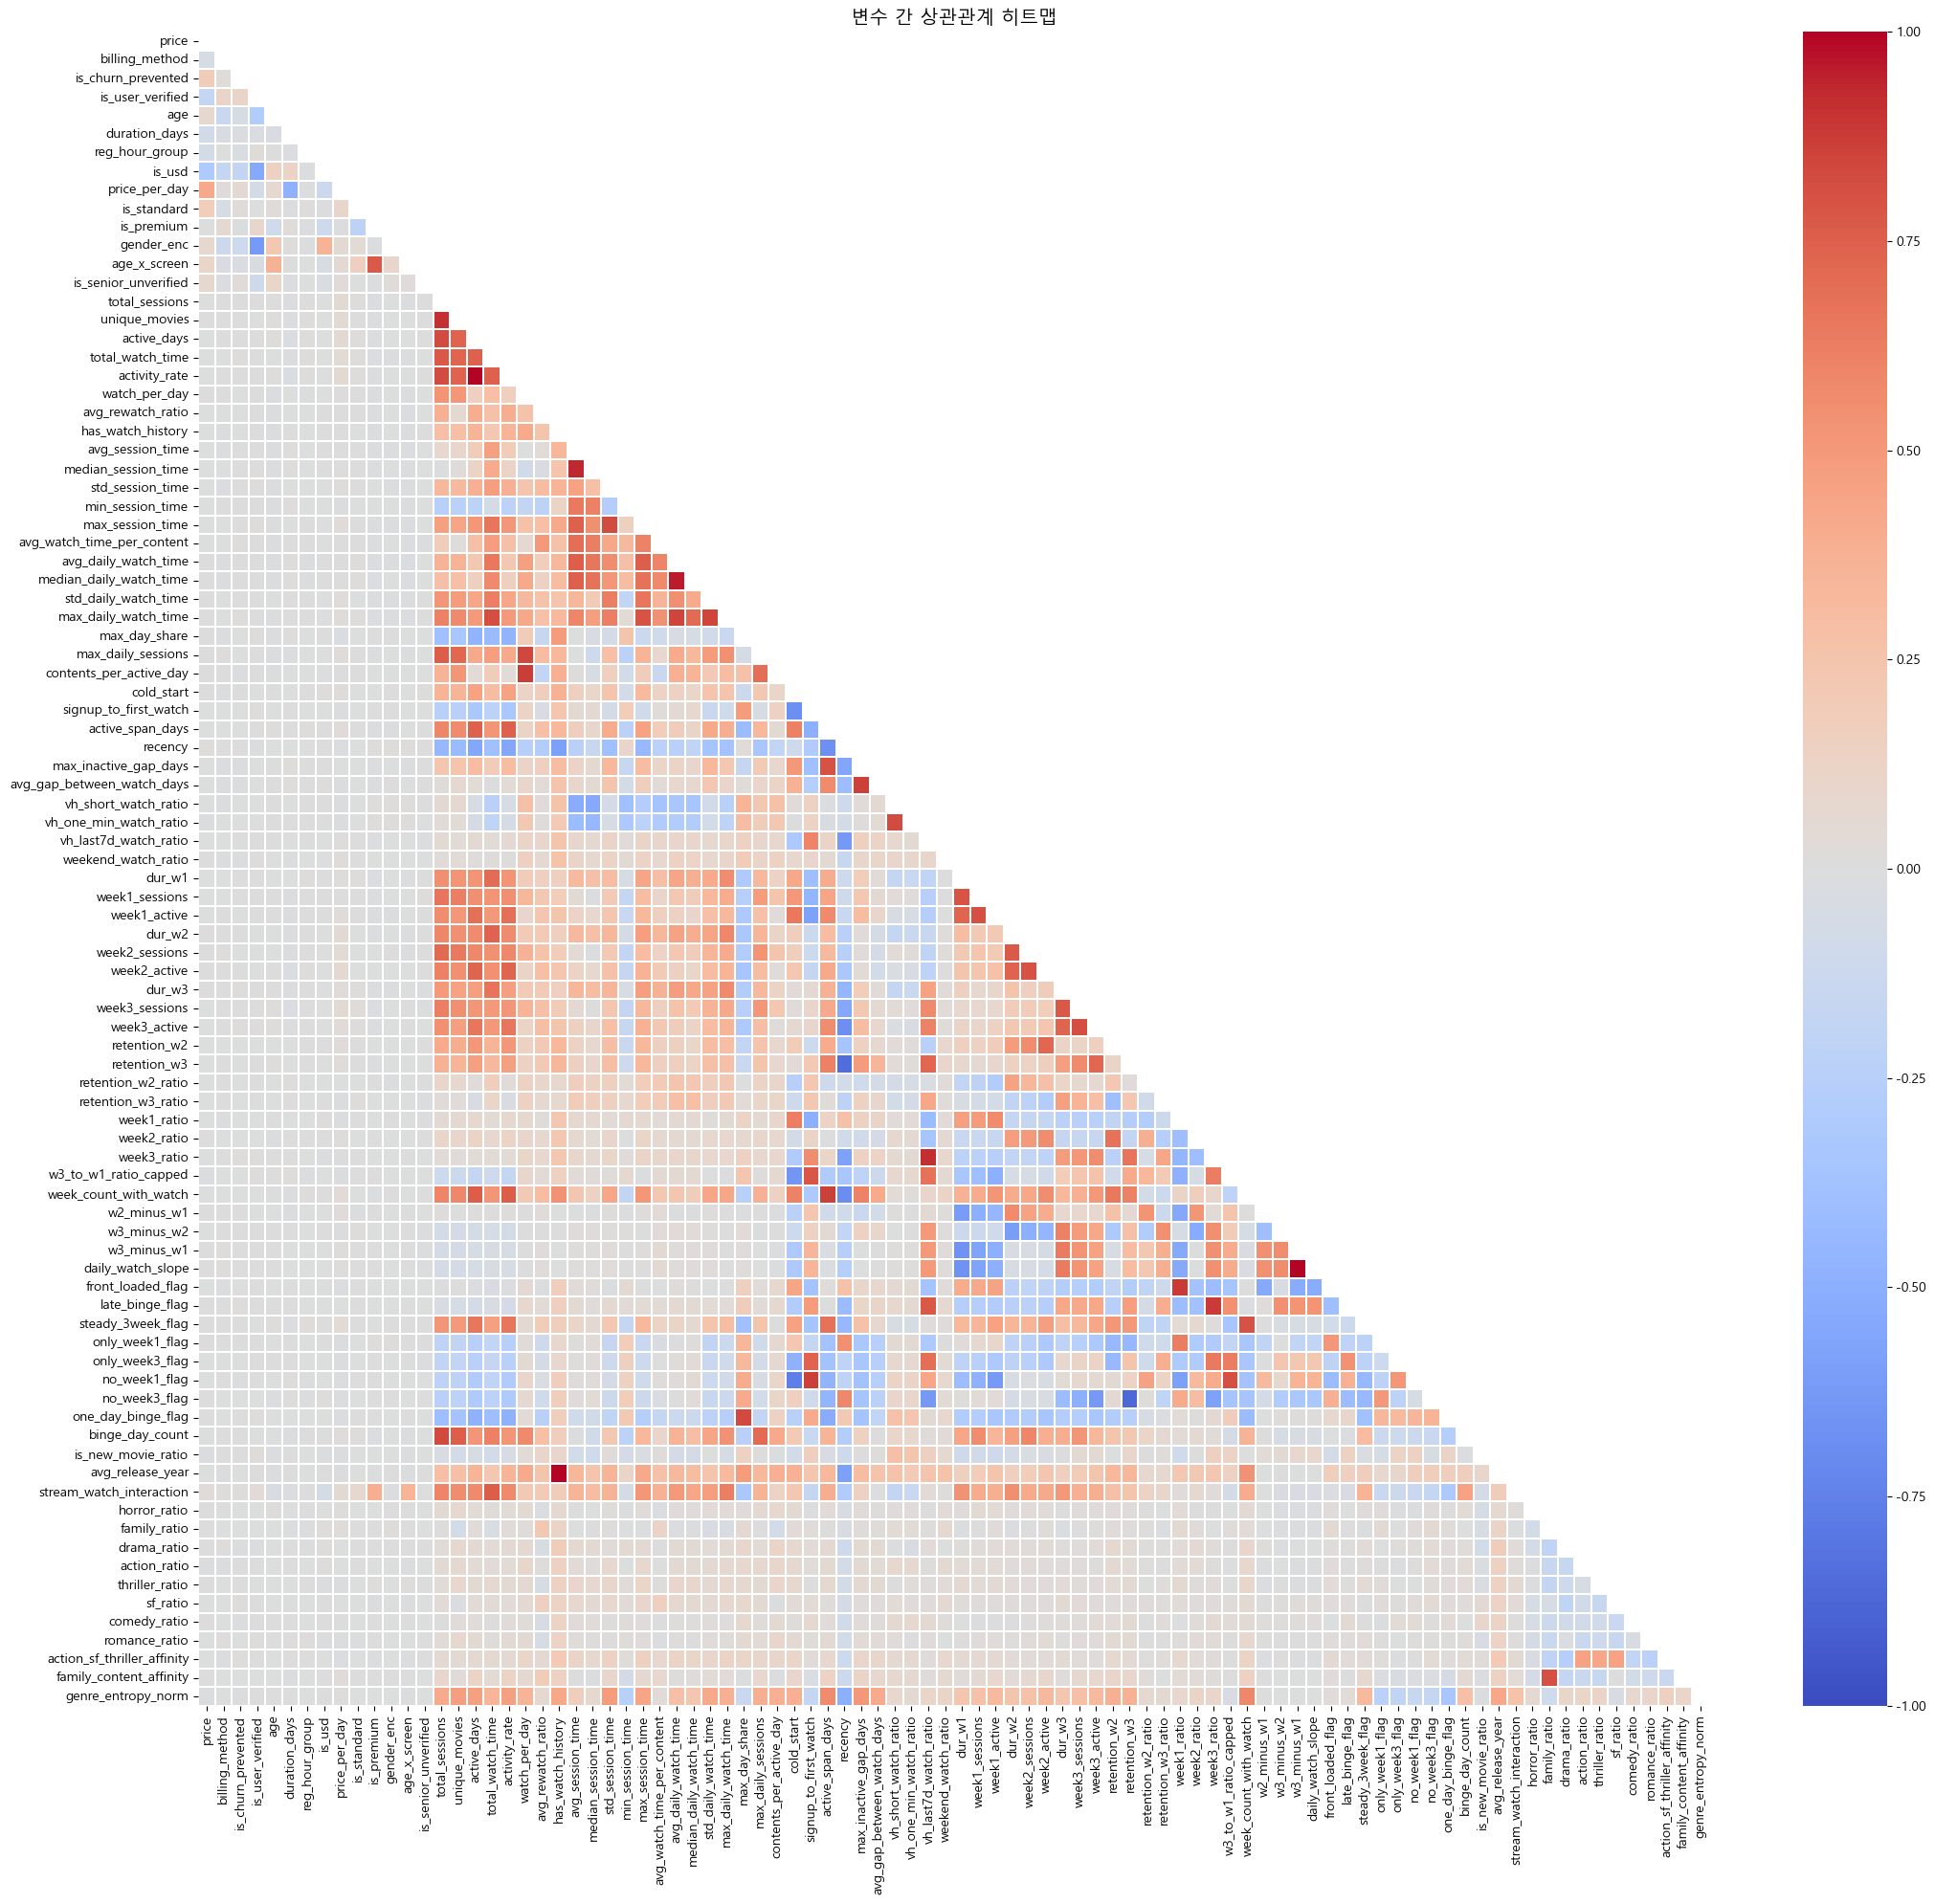

In [3]:
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(22, 20))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.2, ax=ax)
ax.set_title('변수 간 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# |r| >= 0.7 쌍 출력
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.7:
            high_corr.append({'변수1': corr.columns[i], '변수2': corr.columns[j], '상관계수': round(val, 3)})

hc_df = pd.DataFrame(high_corr).sort_values('상관계수', key=abs, ascending=False)
print(f'|r| >= 0.7 쌍: {len(hc_df)}개')
hc_df

|r| >= 0.7 쌍: 71개


,변수1,변수2,상관계수
69,w3_minus_w1,daily_watch_slope,1.000
14,active_days,activity_rate,1.000
27,has_watch_history,avg_release_year,1.000
35,avg_daily_watch_time,median_daily_watch_time,0.954
28,avg_session_time,median_session_time,0.930
...,...,...,...
59,week2_active,retention_w2,0.721
50,vh_last7d_watch_ratio,retention_w3,0.721
6,total_sessions,week2_sessions,0.717
37,median_daily_watch_time,max_daily_watch_time,0.709


## 2. VIF

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_num.copy()
X.insert(0, 'const', 1)

vif_data = pd.DataFrame()
vif_data['변수'] = X.columns[1:]
vif_data['VIF']  = [variance_inflation_factor(X.values, i+1) for i in range(len(X.columns)-1)]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data['위험도'] = vif_data['VIF'].apply(
    lambda v: '🔴 심각' if v > 10 else ('🟡 주의' if v > 5 else '🟢 양호')
)
print(vif_data.to_string())

c:\Users\USER\anaconda4\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                             변수           VIF   위험도
0                        dur_w1           inf  🔴 심각
1                  week3_active           inf  🔴 심각
2             has_watch_history           inf  🔴 심각
3                        dur_w3           inf  🔴 심각
4              total_watch_time           inf  🔴 심각
5                   active_days           inf  🔴 심각
6                  retention_w3           inf  🔴 심각
7                total_sessions           inf  🔴 심각
8                  week2_active           inf  🔴 심각
9                week2_sessions           inf  🔴 심각
10                       dur_w2           inf  🔴 심각
11                 week1_active           inf  🔴 심각
12               week1_sessions           inf  🔴 심각
13                no_week1_flag           inf  🔴 심각
14        signup_to_first_watch           inf  🔴 심각
15        week_count_with_watch           inf  🔴 심각
16                  w2_minus_w1           inf  🔴 심각
17                  w3_minus_w2           inf  🔴 심각
18          

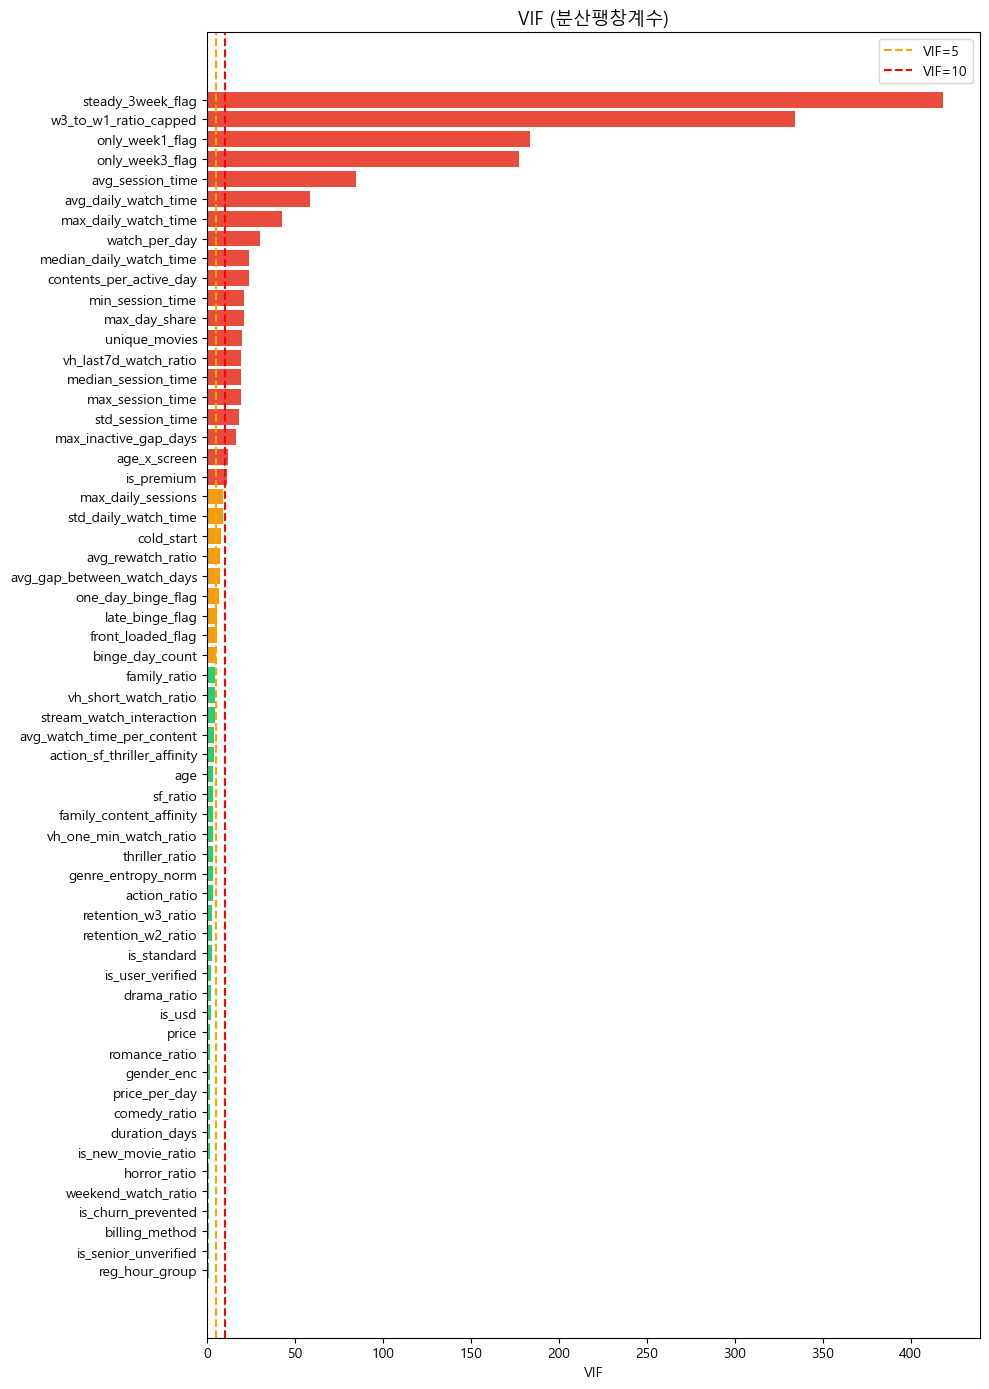

In [6]:
# VIF 시각화
vif_plot = vif_data[vif_data['VIF'] < 1000].copy()  # inf 제외
colors = ['#e74c3c' if v>10 else '#f39c12' if v>5 else '#2ecc71' for v in vif_plot['VIF']]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(vif_plot['변수'][::-1], vif_plot['VIF'][::-1], color=colors[::-1])
ax.axvline(5,  color='orange', linestyle='--', label='VIF=5')
ax.axvline(10, color='red',    linestyle='--', label='VIF=10')
ax.set_title('VIF (분산팽창계수)', fontsize=13)
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 제거 검토 대상

In [7]:
print('=== VIF > 10 (심각) ===')
print(vif_data[vif_data['VIF'] > 10][['변수','VIF']].to_string())
print()
print('=== VIF 5~10 (주의) ===')
print(vif_data[(vif_data['VIF']>5)&(vif_data['VIF']<=10)][['변수','VIF']].to_string())
print()
print('※ XGBoost는 다중공선성에 강함 → VIF inf/심각 변수만 제거 검토, 나머지는 SHAP 후 판단')

=== VIF > 10 (심각) ===
                         변수           VIF
0                    dur_w1           inf
1              week3_active           inf
2         has_watch_history           inf
3                    dur_w3           inf
4          total_watch_time           inf
5               active_days           inf
6              retention_w3           inf
7            total_sessions           inf
8              week2_active           inf
9            week2_sessions           inf
10                   dur_w2           inf
11             week1_active           inf
12           week1_sessions           inf
13            no_week1_flag           inf
14    signup_to_first_watch           inf
15    week_count_with_watch           inf
16              w2_minus_w1           inf
17              w3_minus_w2           inf
18              w3_minus_w1           inf
19         active_span_days           inf
20           week3_sessions           inf
21            no_week3_flag  9.007199e+15
22          

## 4. 다중공선성 기반 변수 제거

In [8]:
SUM_REDUNDANT = [
    'total_watch_time',
    'week1_active','week2_active','week3_active',
    'week1_sessions','week2_sessions','week3_sessions',
]
DERIVED_REDUNDANT = [
    'no_week1_flag','no_week3_flag',
    'w2_minus_w1','w3_minus_w2',
    'active_span_days','signup_to_first_watch',
    'steady_3week_flag',
]
NEAR_CONSTANT = ['has_watch_history']

ALL_DROP = [c for c in SUM_REDUNDANT+DERIVED_REDUNDANT+NEAR_CONSTANT if c in df_raw.columns]
df_clean = df_raw.drop(columns=ALL_DROP)

print(f'제거 전: {df_raw.shape[1]}개')
print(f'제거 수: {len(ALL_DROP)}개')
print(f'제거 후: {df_clean.shape[1]}개')
print('\n제거 변수:', ALL_DROP)

제거 전: 100개
제거 수: 15개
제거 후: 85개

제거 변수: ['total_watch_time', 'week1_active', 'week2_active', 'week3_active', 'week1_sessions', 'week2_sessions', 'week3_sessions', 'no_week1_flag', 'no_week3_flag', 'w2_minus_w1', 'w3_minus_w2', 'active_span_days', 'signup_to_first_watch', 'steady_3week_flag', 'has_watch_history']


## 5. 제거 후 VIF 재확인

In [9]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

DROP2 = ['USER_KEY','product_code','payment_device','device_group',
         'gender','age_group','is_repurchase','is_promotion']
DROP2 = [c for c in DROP2 if c in df_clean.columns]

df_num2 = df_clean.drop(columns=DROP2).select_dtypes(include=[np.number]).fillna(0)
df_num2 = df_num2.drop(columns=[c for c in df_num2.columns if df_num2[c].var()==0])

X2 = df_num2.copy()
X2.insert(0, 'const', 1)

vif2 = pd.DataFrame()
vif2['변수'] = X2.columns[1:]
vif2['VIF']  = [variance_inflation_factor(X2.values, i+1) for i in range(len(X2.columns)-1)]
vif2 = vif2.sort_values('VIF', ascending=False).reset_index(drop=True)
vif2['위험도'] = vif2['VIF'].apply(lambda v: '🔴 심각' if v>10 else ('🟡 주의' if v>5 else '🟢 양호'))
print(f'분석 변수: {df_num2.shape[1]}개')
print(vif2.to_string())

c:\Users\USER\anaconda4\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


분석 변수: 77개
                             변수           VIF   위험도
0                   w3_minus_w1           inf  🔴 심각
1                        dur_w3           inf  🔴 심각
2       contents_per_active_day           inf  🔴 심각
3                 watch_per_day           inf  🔴 심각
4          vh_title_div_per_day           inf  🔴 심각
5                        dur_w1           inf  🔴 심각
6       sessions_per_active_day           inf  🔴 심각
7             daily_watch_slope  3.063777e+11  🔴 심각
8                 activity_rate  2.540595e+07  🔴 심각
9                   active_days  2.539747e+07  🔴 심각
10                  week3_ratio  2.009593e+05  🔴 심각
11                  week1_ratio  2.001105e+05  🔴 심각
12                  week2_ratio  1.841478e+05  🔴 심각
13             avg_release_year  9.221356e+04  🔴 심각
14             avg_session_time  8.437364e+01  🔴 심각
15        week_count_with_watch  6.301746e+01  🔴 심각
16         avg_daily_watch_time  5.798263e+01  🔴 심각
17               total_sessions  4.349016e+01  🔴 심각
1

## 6. 최종 데이터 저장

In [10]:
out_path = BASE / '_data/02_interim/260510_features/Membership_features_clean.csv'
df_clean.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {out_path}')
print(f'최종 shape: {df_clean.shape}')
print(f'제거: {df_raw.shape[1]-df_clean.shape[1]}개 | 잔여: {df_clean.shape[1]}개')

저장 완료: C:\Users\USER\OneDrive\바탕 화면\AX git\ott-churn-prediction\kwon.donggeun\_data\02_interim\260510_features\Membership_features_clean.csv
최종 shape: (23343, 85)
제거: 15개 | 잔여: 85개


In [11]:
# 2차 제거: VIF 재확인 후 발견된 완전 중복
DROP2 = [
    'vh_title_div_per_day',    # = contents_per_active_day
    'sessions_per_active_day', # = watch_per_day
    'daily_watch_slope',       # = w3_minus_w1 / 14
    'week_count_with_watch',   # 이전 제거 누락
]
DROP2 = [c for c in DROP2 if c in df_clean.columns]
df_clean = df_clean.drop(columns=DROP2)

# 저장
out_path = BASE / '_data/02_interim/260510_features/Membership_features_clean.csv'
df_clean.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'2차 제거: {len(DROP2)}개 → 최종 {df_clean.shape[1]}개 컬럼')
print(f'저장 완료: {out_path}')

2차 제거: 4개 → 최종 81개 컬럼
저장 완료: C:\Users\USER\OneDrive\바탕 화면\AX git\ott-churn-prediction\kwon.donggeun\_data\02_interim\260510_features\Membership_features_clean.csv


In [12]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

DROP2 = ['USER_KEY','product_code','payment_device','device_group',
         'gender','age_group','is_repurchase','is_promotion']
DROP2 = [c for c in DROP2 if c in df_clean.columns]

df_num2 = df_clean.drop(columns=DROP2).select_dtypes(include=[np.number]).fillna(0)
df_num2 = df_num2.drop(columns=[c for c in df_num2.columns if df_num2[c].var()==0])

X2 = df_num2.copy()
X2.insert(0, 'const', 1)

vif2 = pd.DataFrame()
vif2['변수'] = X2.columns[1:]
vif2['VIF']  = [variance_inflation_factor(X2.values, i+1) for i in range(len(X2.columns)-1)]
vif2 = vif2.sort_values('VIF', ascending=False).reset_index(drop=True)
vif2['위험도'] = vif2['VIF'].apply(lambda v: '🔴 심각' if v>10 else ('🟡 주의' if v>5 else '🟢 양호'))
print(f'분석 변수: {df_num2.shape[1]}개')
print(vif2.to_string())

c:\Users\USER\anaconda4\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


분석 변수: 73개
                             변수           VIF   위험도
0                   w3_minus_w1           inf  🔴 심각
1                        dur_w3           inf  🔴 심각
2                        dur_w1           inf  🔴 심각
3                 activity_rate  2.525992e+07  🔴 심각
4                   active_days  2.525175e+07  🔴 심각
5                   week3_ratio  2.009396e+05  🔴 심각
6                   week1_ratio  2.000839e+05  🔴 심각
7                   week2_ratio  1.841356e+05  🔴 심각
8              avg_release_year  9.220910e+04  🔴 심각
9              avg_session_time  8.436915e+01  🔴 심각
10         avg_daily_watch_time  5.795516e+01  🔴 심각
11               total_sessions  4.348350e+01  🔴 심각
12         max_daily_watch_time  4.201047e+01  🔴 심각
13                watch_per_day  2.978365e+01  🔴 심각
14      median_daily_watch_time  2.359242e+01  🔴 심각
15      contents_per_active_day  2.346310e+01  🔴 심각
16             min_session_time  2.108318e+01  🔴 심각
17                max_day_share  2.058803e+01  🔴 심각
1